## Wiener baseline for ECG ink removal

We keep the same Wiener Fourier method.
The only change is the ink image.

We now:
- load a **clean** ECG image (`0001`)
- generate a **synthetic ink** image from that clean image
- learn the Wiener filter on one ECG
- transfer that filter to another ECG

### Why synthetic ink
This removes padding and alignment issues.
The clean image and the synthetic ink image have the same size.

### Filter
Let:
- $x$ = clean image
- $y$ = synthetic ink image

We estimate the Wiener-type restoration filter

$$W(u,v)=\frac{X(u,v)\,\overline{Y(u,v)}}{|Y(u,v)|^2+K},$$

where:
- $X$ is the Fourier transform of the clean image,
- $Y$ is the Fourier transform of the synthetic ink image,
- $K>0$ is a small regularization constant.

Then, for a new synthetic ink image $y_{\text{test}}$, we compute

$$\widehat{X}_{\text{test}}(u,v)=W(u,v)\,Y_{\text{test}}(u,v).$$

### Goal
This notebook keeps the linear Wiener method unchanged.
So you can compare it more fairly with the closing notebook on synthetic ink.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# Data and Wiener configuration
# -----------------------------
base_path = Path("../../data/sample")

train_id = "10140238"
test_id = "11842146"
clean_scan = "0001"

# Synthetic ink settings.
# Keep these close to the closing notebook if you want an easier comparison.
TRAIN_SEED = 10
TEST_SEED = 19
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5

K_WIENER = 1e-3


# -----------------------------
# I/O
# -----------------------------
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img.astype(np.float32) / 255.0, path


# -----------------------------
# Synthetic ink
# -----------------------------
def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.60))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.50))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


# -----------------------------
# FFT helpers
# -----------------------------
def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(img))


def ifft2c(F):
    return np.fft.ifft2(np.fft.ifftshift(F)).real


def radial_profile(data, center=None):
    h, w = data.shape
    if center is None:
        center = (h // 2, w // 2)

    y, x = np.indices((h, w))
    r = np.sqrt((x - center[1]) ** 2 + (y - center[0]) ** 2).astype(np.int32)

    tbin = np.bincount(r.ravel(), weights=data.ravel())
    nr = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)


# -----------------------------
# Wiener filter from one pair
# -----------------------------
def estimate_wiener_filter_from_pair(clean_img, ink_img, K=1e-3):
    X = fft2c(clean_img)
    Y = fft2c(ink_img)
    W = (X * np.conj(Y)) / (np.abs(Y) ** 2 + K)
    return W, X, Y


def apply_wiener_filter(ink_img, W):
    Y = fft2c(ink_img)
    X_hat = W * Y
    restored = np.clip(ifft2c(X_hat), 0.0, 1.0)
    return restored, Y, X_hat


def mae(a, b):
    return float(np.mean(np.abs(a - b)))


def masked_mae(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


Training clean path: ..\..\data\sample\10140238\10140238-0001.png
Training synthetic seed: 10
Training shape: (1700, 2200)

Training MAE before Wiener (all pixels): 0.02050238847732544
Training MAE after Wiener  (all pixels): 2.731611857598182e-06
Training MAE before Wiener (true ink mask): 0.1643277108669281
Training MAE after Wiener  (true ink mask): 2.7328767373546725e-06


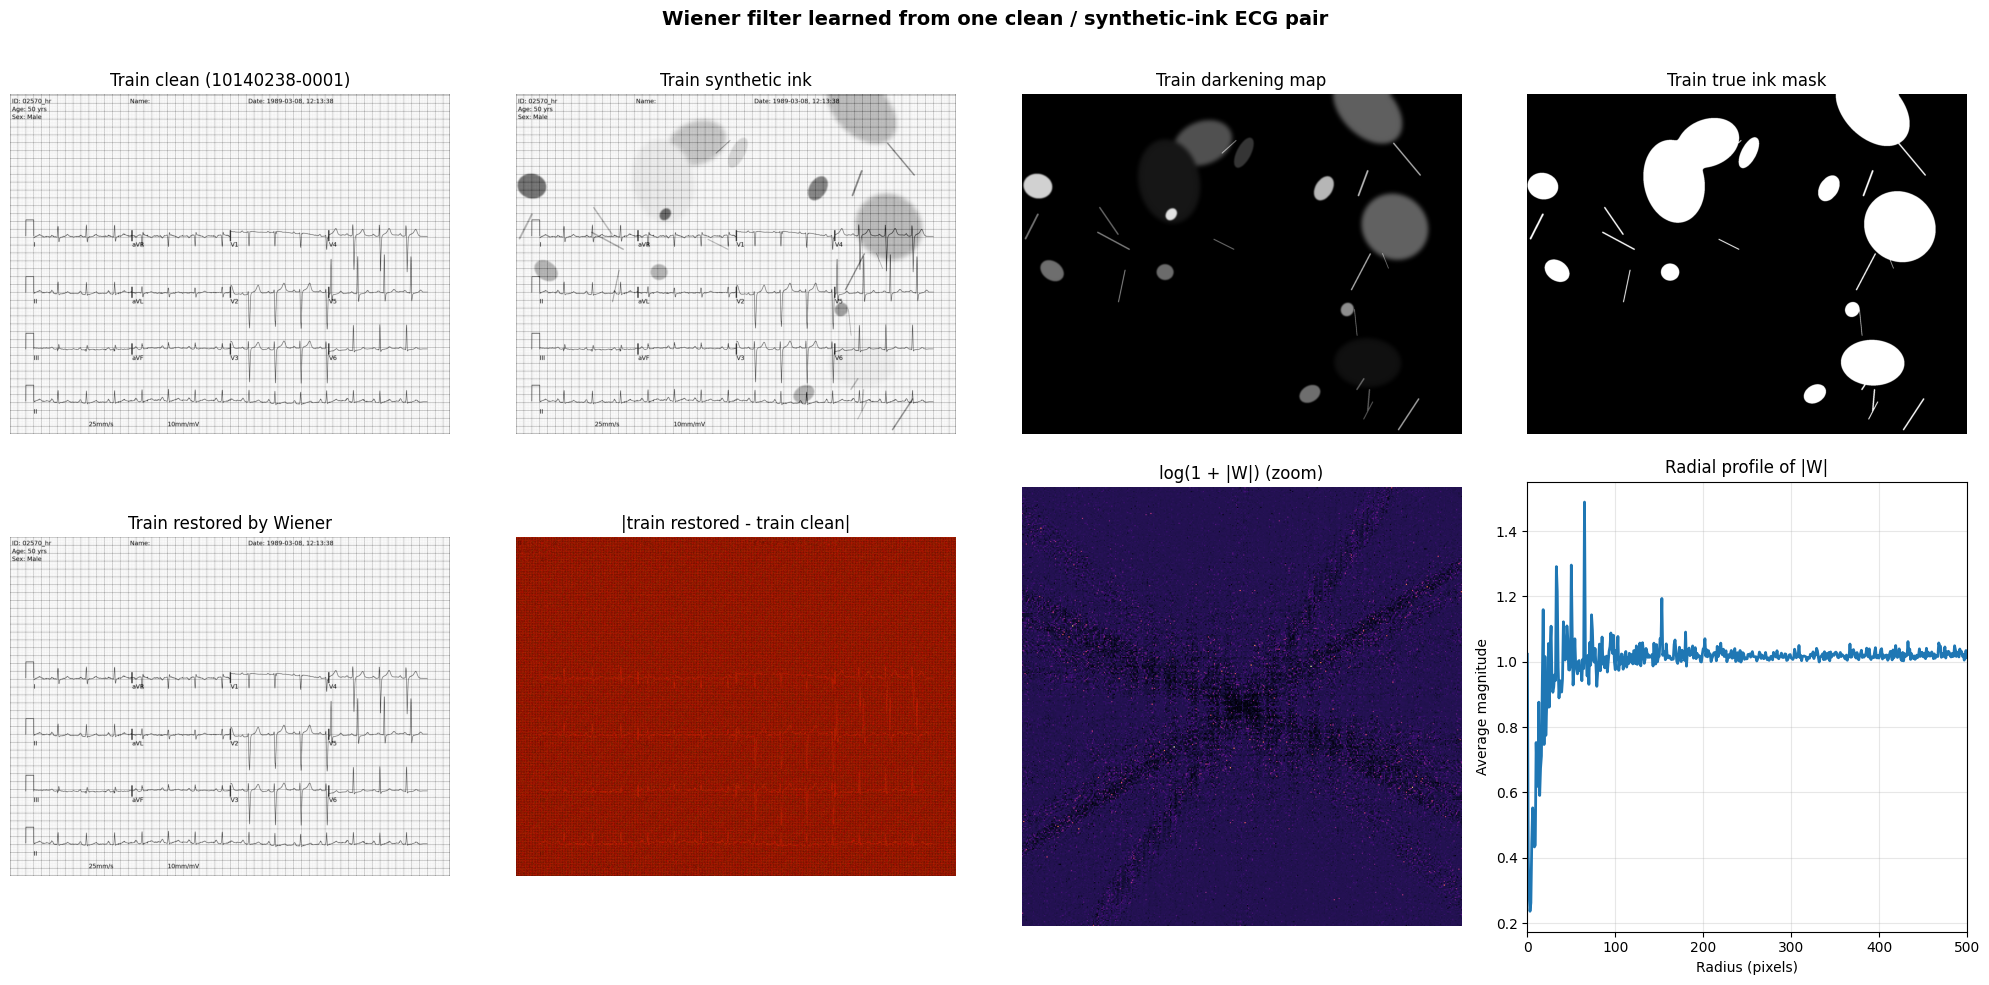

In [2]:
# -----------------------------------------
# Learn Wiener filter from the training pair
# -----------------------------------------
train_clean, train_clean_path = load_gray_image(train_id, clean_scan)
train_ink, train_darkening, train_true_mask = generate_random_ink_from_clean(
    train_clean,
    seed=TRAIN_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

W, X_train, Y_train = estimate_wiener_filter_from_pair(train_clean, train_ink, K=K_WIENER)
train_restored, _, Xhat_train = apply_wiener_filter(train_ink, W)

print("Training clean path:", train_clean_path)
print("Training synthetic seed:", TRAIN_SEED)
print("Training shape:", train_clean.shape)
print()
print("Training MAE before Wiener (all pixels):", mae(train_ink, train_clean))
print("Training MAE after Wiener  (all pixels):", mae(train_restored, train_clean))
print("Training MAE before Wiener (true ink mask):", masked_mae(train_ink, train_clean, train_true_mask))
print("Training MAE after Wiener  (true ink mask):", masked_mae(train_restored, train_clean, train_true_mask))

W_mag = np.abs(W)
W_log_mag = np.log1p(W_mag)
W_radial = radial_profile(W_mag)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0, 0].imshow(train_clean, cmap="gray")
axes[0, 0].set_title(f"Train clean ({train_id}-{clean_scan})")
axes[0, 0].axis("off")

axes[0, 1].imshow(train_ink, cmap="gray")
axes[0, 1].set_title("Train synthetic ink")
axes[0, 1].axis("off")

axes[0, 2].imshow(train_darkening, cmap="gray")
axes[0, 2].set_title("Train darkening map")
axes[0, 2].axis("off")

axes[0, 3].imshow(train_true_mask, cmap="gray")
axes[0, 3].set_title("Train true ink mask")
axes[0, 3].axis("off")

axes[1, 0].imshow(train_restored, cmap="gray")
axes[1, 0].set_title("Train restored by Wiener")
axes[1, 0].axis("off")

axes[1, 1].imshow(np.abs(train_restored - train_clean), cmap="hot")
axes[1, 1].set_title("|train restored - train clean|")
axes[1, 1].axis("off")

zoom = 180
cy, cx = W_log_mag.shape[0] // 2, W_log_mag.shape[1] // 2
axes[1, 2].imshow(W_log_mag[cy - zoom:cy + zoom, cx - zoom:cx + zoom], cmap="magma")
axes[1, 2].set_title("log(1 + |W|) (zoom)")
axes[1, 2].axis("off")

axes[1, 3].plot(W_radial, linewidth=2)
axes[1, 3].set_title("Radial profile of |W|")
axes[1, 3].set_xlabel("Radius (pixels)")
axes[1, 3].set_ylabel("Average magnitude")
axes[1, 3].set_xlim(0, min(500, len(W_radial)))
axes[1, 3].grid(True, alpha=0.3)

plt.suptitle("Wiener filter learned from one clean / synthetic-ink ECG pair", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


Test clean path: ..\..\data\sample\11842146\11842146-0001.png
Test synthetic seed: 19
Test shape: (1700, 2200)

Test MAE before Wiener (all pixels): 0.015497807413339615
Test MAE after Wiener  (all pixels): 0.05146617814898491
Test MAE before Wiener (true ink mask): 0.16926197707653046
Test MAE after Wiener  (true ink mask): 0.0673108920454979


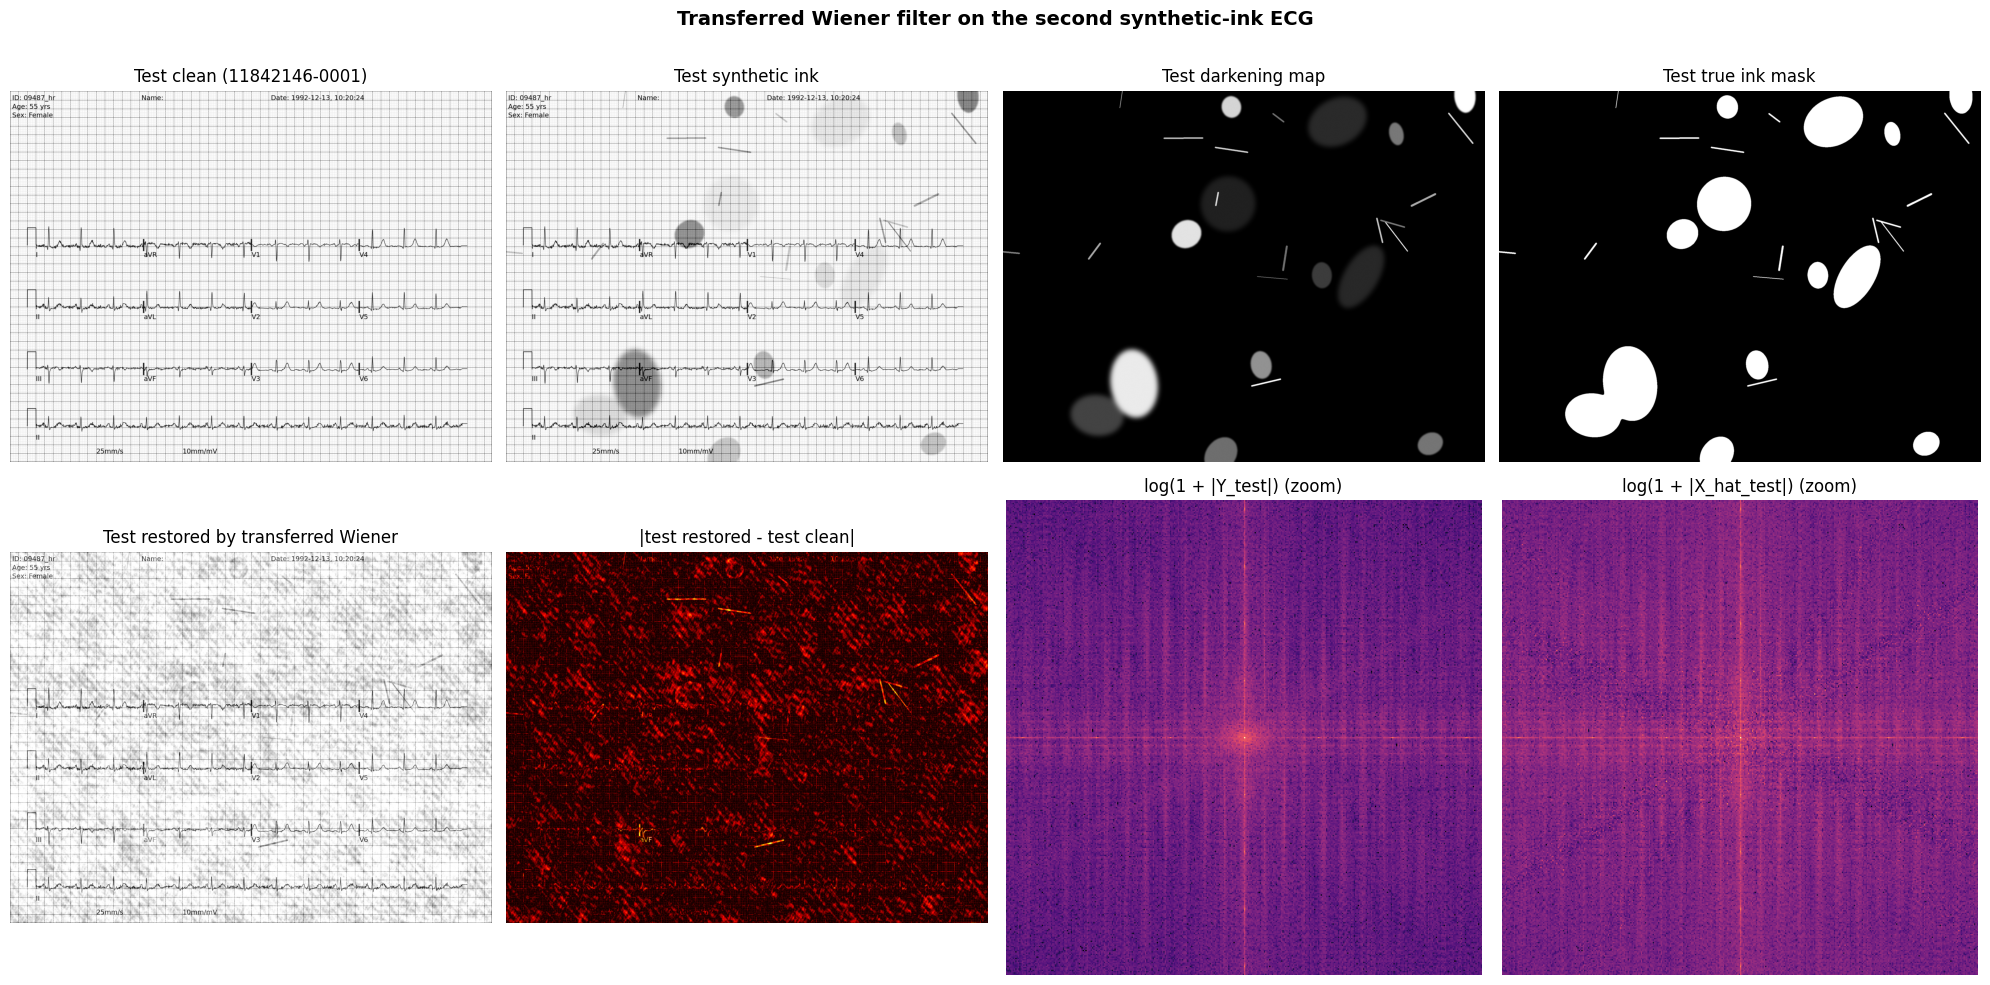

In [3]:
# ------------------------------------------
# Apply the learned Wiener filter to the test
# ------------------------------------------
test_clean, test_clean_path = load_gray_image(test_id, clean_scan)
test_ink, test_darkening, test_true_mask = generate_random_ink_from_clean(
    test_clean,
    seed=TEST_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

test_restored, Y_test, Xhat_test = apply_wiener_filter(test_ink, W)

print("Test clean path:", test_clean_path)
print("Test synthetic seed:", TEST_SEED)
print("Test shape:", test_clean.shape)
print()
print("Test MAE before Wiener (all pixels):", mae(test_ink, test_clean))
print("Test MAE after Wiener  (all pixels):", mae(test_restored, test_clean))
print("Test MAE before Wiener (true ink mask):", masked_mae(test_ink, test_clean, test_true_mask))
print("Test MAE after Wiener  (true ink mask):", masked_mae(test_restored, test_clean, test_true_mask))

logY_test = np.log1p(np.abs(Y_test))
logXhat_test = np.log1p(np.abs(Xhat_test))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes[0, 0].imshow(test_clean, cmap="gray")
axes[0, 0].set_title(f"Test clean ({test_id}-{clean_scan})")
axes[0, 0].axis("off")

axes[0, 1].imshow(test_ink, cmap="gray")
axes[0, 1].set_title("Test synthetic ink")
axes[0, 1].axis("off")

axes[0, 2].imshow(test_darkening, cmap="gray")
axes[0, 2].set_title("Test darkening map")
axes[0, 2].axis("off")

axes[0, 3].imshow(test_true_mask, cmap="gray")
axes[0, 3].set_title("Test true ink mask")
axes[0, 3].axis("off")

axes[1, 0].imshow(test_restored, cmap="gray")
axes[1, 0].set_title("Test restored by transferred Wiener")
axes[1, 0].axis("off")

axes[1, 1].imshow(np.abs(test_restored - test_clean), cmap="hot")
axes[1, 1].set_title("|test restored - test clean|")
axes[1, 1].axis("off")

zoom = 180
cy, cx = logY_test.shape[0] // 2, logY_test.shape[1] // 2
axes[1, 2].imshow(logY_test[cy - zoom:cy + zoom, cx - zoom:cx + zoom], cmap="magma")
axes[1, 2].set_title("log(1 + |Y_test|) (zoom)")
axes[1, 2].axis("off")

axes[1, 3].imshow(logXhat_test[cy - zoom:cy + zoom, cx - zoom:cx + zoom], cmap="magma")
axes[1, 3].set_title("log(1 + |X_hat_test|) (zoom)")
axes[1, 3].axis("off")

plt.suptitle("Transferred Wiener filter on the second synthetic-ink ECG", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


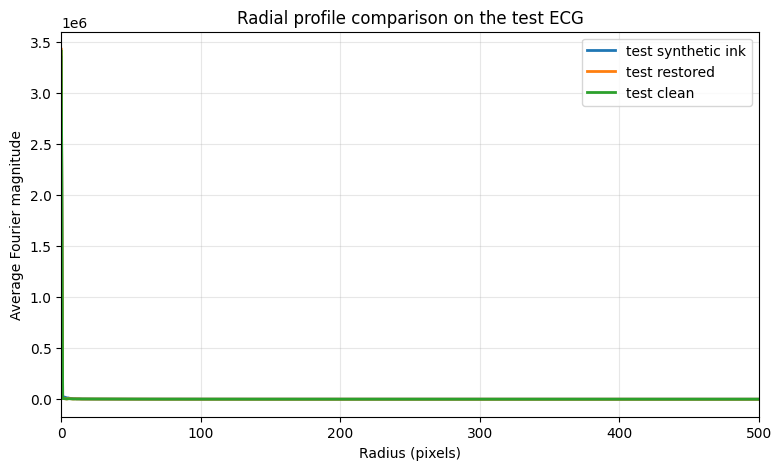

In [4]:
# ------------------------------------------
# Radial-profile comparison on the test image
# ------------------------------------------
rad_ink = radial_profile(np.abs(Y_test))
rad_restored = radial_profile(np.abs(Xhat_test))
rad_clean = radial_profile(np.abs(fft2c(test_clean)))

plt.figure(figsize=(9, 5))
plt.plot(rad_ink, label="test synthetic ink", linewidth=2)
plt.plot(rad_restored, label="test restored", linewidth=2)
plt.plot(rad_clean, label="test clean", linewidth=2)
plt.xlim(0, min(500, len(rad_clean)))
plt.xlabel("Radius (pixels)")
plt.ylabel("Average Fourier magnitude")
plt.title("Radial profile comparison on the test ECG")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Conclusion

Saved test result on `11842146`:
- before Wiener: all-pixel MAE `0.026445`, ink-mask MAE `0.282382`
- after Wiener: all-pixel MAE `0.058076`, ink-mask MAE `0.078060`

So Wiener helps on the ink region, but it makes the full image worse.
The training pair is fit almost perfectly, but the transferred filter does not generalize well.
For this synthetic case, Wiener is useful as a linear Fourier baseline, not as the best restoration method.
